# Telecom Customer Churn Analysis
## Business Analysis Internship Project

### Prepared By: Yash Kumar

### Technologies Used
- Python
- Pandas
- Seaborn
- Matplotlib
- Plotly
- Google Colab

In [95]:
# IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

sns.set(style='whitegrid')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [96]:
from google.colab import files

uploaded = files.upload()

Saving Telco_Customer_Churn_Dataset  (3).csv to Telco_Customer_Churn_Dataset  (3) (3).csv


In [97]:
import pandas as pd

df = pd.read_csv("Telco_Customer_Churn_Dataset  (3).csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset Understanding

In [98]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [99]:
print(df.shape)

(7043, 21)


In [100]:
df.dtypes
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Data Cleaning

In [101]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [102]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicates: 0


In [103]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

In [104]:

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [105]:
df.isnull().sum()

,0
customerid,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0
onlinesecurity,0


Exploratory Data Analysis (EDA)

In [106]:
df.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [107]:
for col in num_cols:
    print(f"\nColumn: {col}")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])


Column: seniorcitizen
Mean: 0.1621468124378816
Median: 0.0
Mode: 0

Column: tenure
Mean: 32.37114865824223
Median: 29.0
Mode: 1

Column: monthlycharges
Mean: 64.76169246059918
Median: 70.35
Mode: 20.05

Column: totalcharges
Mean: 2281.9169281556156
Median: 1397.475
Mode: 20.2


Distribution Of numerical Variables (with KDE)

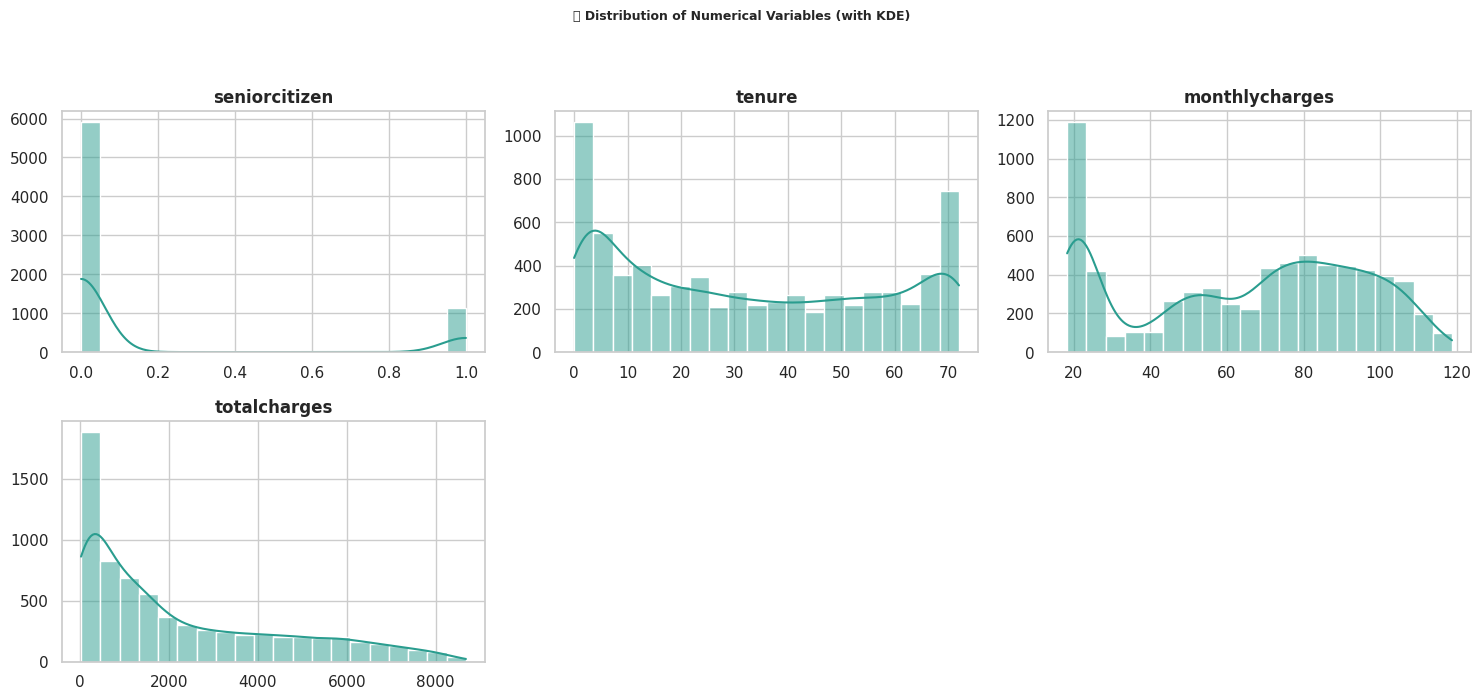

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)

    sns.histplot(df[col], bins=20, kde=True, color='#2A9D8F')

    plt.title(col, fontsize=12, fontweight='bold')
    plt.xlabel("")
    plt.ylabel("")

plt.suptitle(
    "📊 Distribution of Numerical Variables (with KDE)",
    fontsize=9,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Boxplots

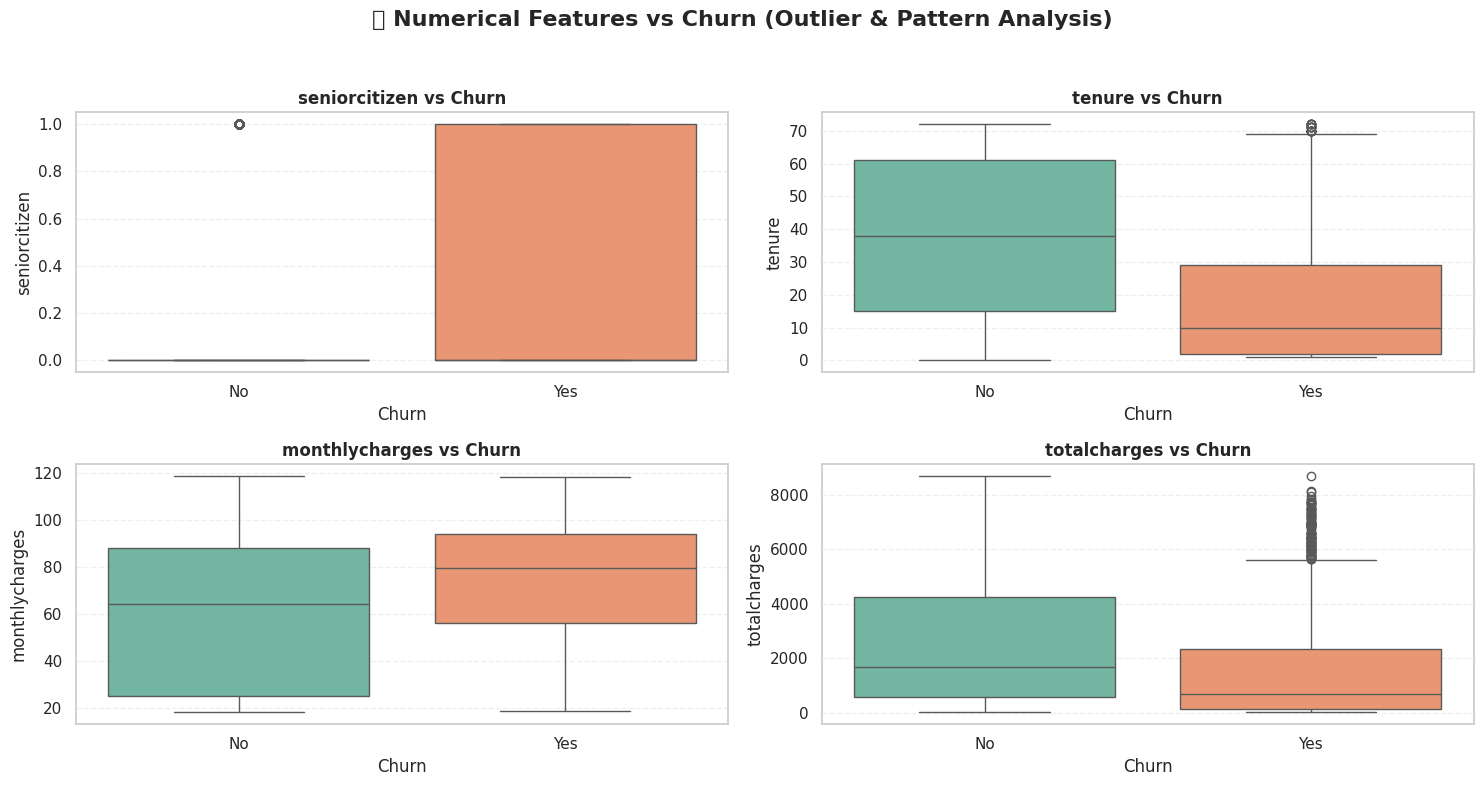

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)

    sns.boxplot(
        x='churn',
        y=col,
        data=df,
        palette='Set2'
    )

    plt.title(f"{col} vs Churn", fontsize=12, fontweight='bold')
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle(
    "📊 Numerical Features vs Churn (Outlier & Pattern Analysis)",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Churn Distribution

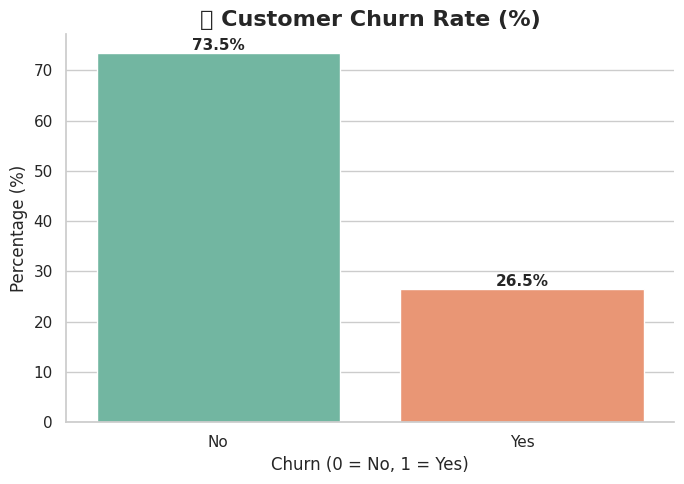

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=df['churn'].value_counts().index,
    y=df['churn'].value_counts(normalize=True) * 100,
    palette='Set2'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("📊 Customer Churn Rate (%)", fontsize=16, fontweight='bold')
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Percentage (%)")

sns.despine()
plt.tight_layout()
plt.show()

Correlation Heatmap

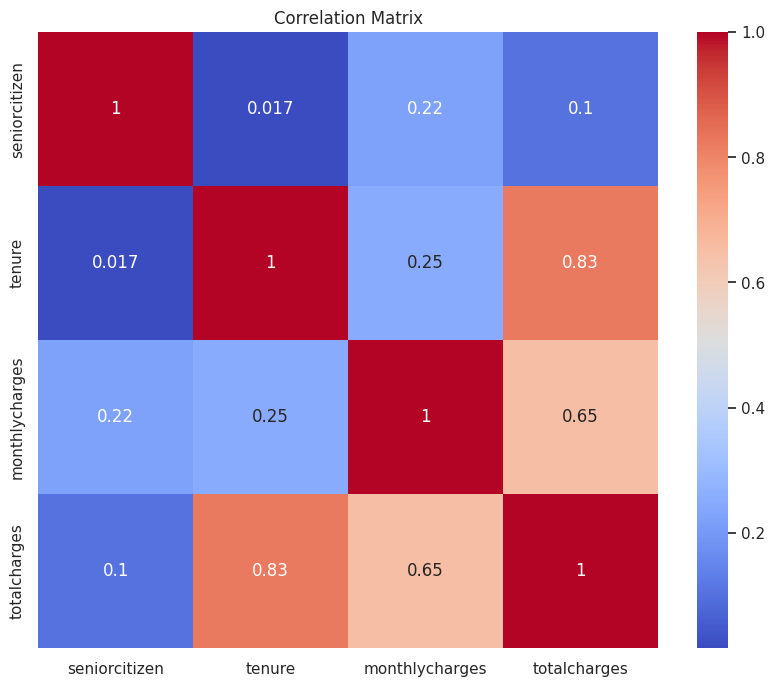

In [111]:
correlation = df[num_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

Customer Segmentation

In [112]:
import pandas as pd
import plotly.express as px

# Create tenure groups
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 36, df['tenure'].max()],
    labels=['0-12 Months', '13-36 Months', '37+ Months'],
    include_lowest=True
)


group_data = df['tenure_group'].value_counts().sort_index()


fig = px.pie(
    values=group_data.values,
    names=group_data.index,
    hole=0.6,
    color=group_data.index,
    color_discrete_sequence=['#00CC96', '#FFA15A', '#EF553B']
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    pull=[0.03, 0.03, 0.08],  # Highlight largest segment
    marker=dict(line=dict(color='white', width=3))
)

fig.update_layout(
    title={
        'text': '📊 Customer Distribution by Tenure Group',
        'x': 0.5,
        'font': {'size': 24}
    },
    annotations=[
        dict(
            text=f"<b>{len(df):,}</b><br>Customers",
            x=0.5,
            y=0.5,
            showarrow=False,
            font=dict(size=18)
        )
    ],
    template='plotly_white',
    legend_title='Tenure Group'
)

Clustered Bar

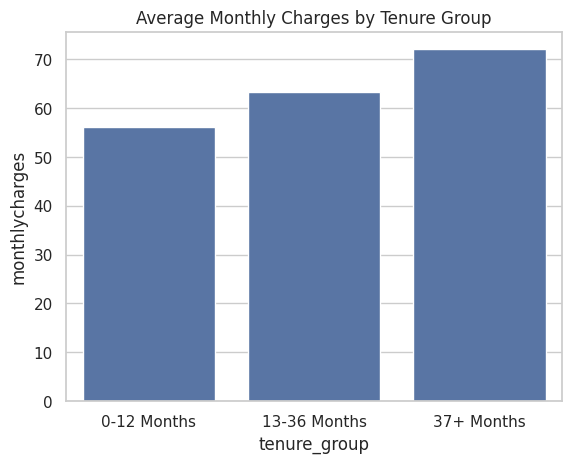

In [113]:
avg_charges = df.groupby('tenure_group')['monthlycharges'].mean().reset_index()

sns.barplot(
    x='tenure_group',
    y='monthlycharges',
    data=avg_charges
)

plt.title("Average Monthly Charges by Tenure Group")

plt.show()

Additional Business Analysis

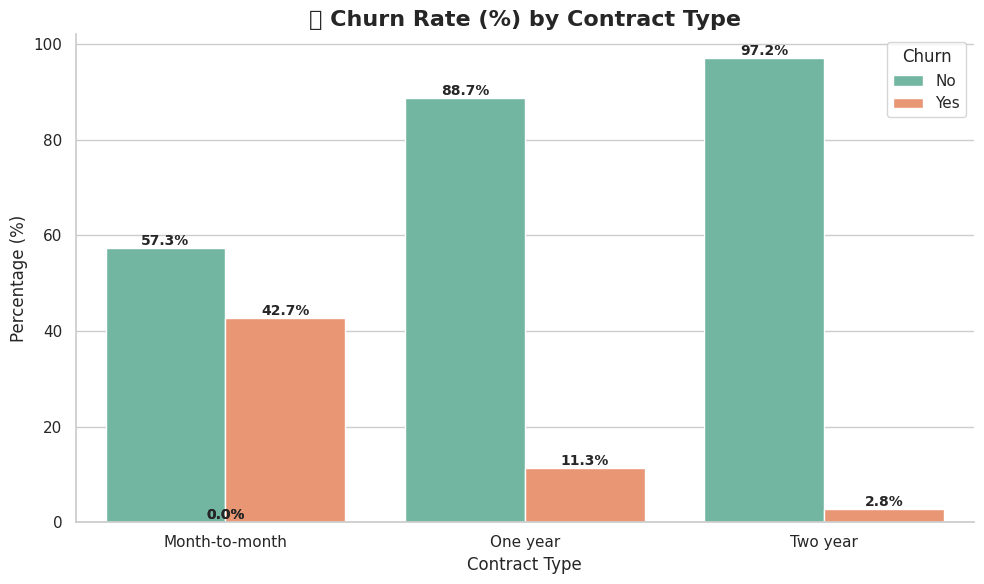

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

contract_churn = (
    df.groupby(['contract', 'churn'])
    .size()
    .reset_index(name='count')
)

# Convert to percentage
contract_churn['percent'] = contract_churn.groupby('contract')['count'].transform(lambda x: x / x.sum() * 100)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=contract_churn,
    x='contract',
    y='percent',
    hue='churn',
    palette='Set2'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("📊 Churn Rate (%) by Contract Type", fontsize=16, fontweight='bold')
plt.ylabel("Percentage (%)")
plt.xlabel("Contract Type")
plt.legend(title="Churn")

sns.despine()
plt.tight_layout()
plt.show()

Churn by Internet Service

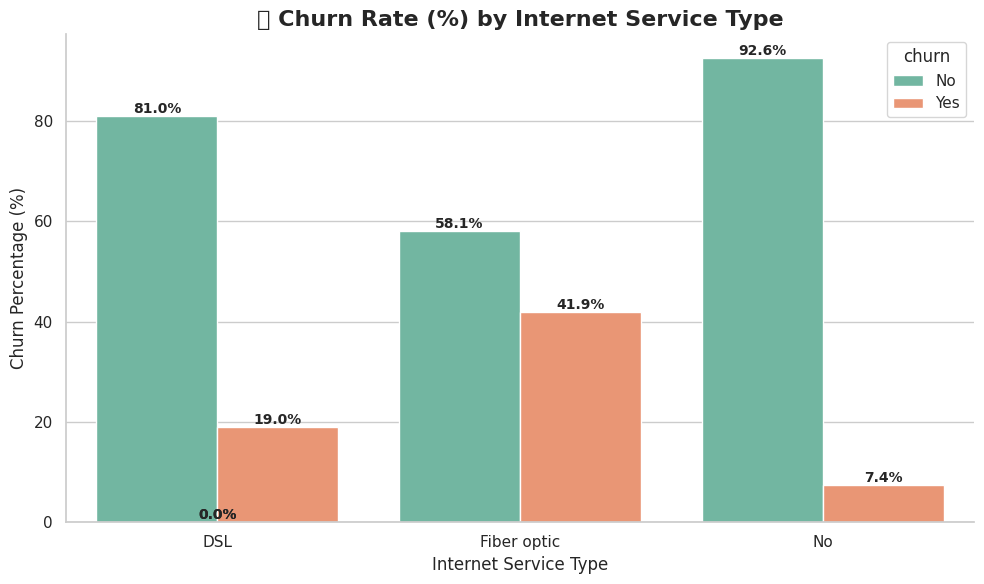

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

internet_churn = (
    df.groupby(['internetservice', 'churn'])
    .size()
    .reset_index(name='count')
)

internet_churn['percent'] = internet_churn.groupby('internetservice')['count'].transform(
    lambda x: x / x.sum() * 100
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=internet_churn,
    x='internetservice',
    y='percent',
    hue='churn',
    palette='Set2'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("📊 Churn Rate (%) by Internet Service Type", fontsize=16, fontweight='bold')
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Percentage (%)")

sns.despine()
plt.tight_layout()
plt.show()

# Final Conclusion

This project analyzed **7,043 Telecom customers** across **21 features** to identify key churn drivers.

### Key Findings:
- **26.5%** of customers churned — 1 in 4 customers is leaving
- **Month-to-month** customers churn at **42.7%** vs only **2.8%** for two-year contracts
- **Fiber Optic** users churn at **41.9%** vs DSL at **19%**
- **New customers (0-12 months)** are the highest risk group
- **Tenure & Total Charges** have a strong correlation of **0.83** — loyal customers = more revenue

The analysis proves that contract type, internet service, and tenure are the 3 biggest churn predictors.

# Business Recommendations

1. Improve onboarding experience for new customers.

2. Offer discounts for yearly and long-term contracts.

3. Create customer loyalty reward programs.

4. Monitor high monthly charge customers closely.

5. Improve customer support quality and response time.

6. Use predictive analytics to identify churn-risk customers early.

7. Create personalized retention campaigns for high-risk customers.